In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt

In [2]:
df_aadi=pd.read_csv('aaditya_cleaning.csv')
df_mahak=pd.read_csv('mahak_cleaning.csv')

In [3]:
aadi_col=['pages','publishDate','firstPublishDate','likedPercent','price','description','characters','awards','setting','length','numofchar','numofawards','title','author','bbeScore']
mahal_col=['series','language','bookFormat','edition','publisher','coverImg','bookId','genres','ratingsByStars','bbeVotes','isbn','isSeries','formatCategory','rating','numRatings']

In [4]:
df_aadi_clean=df_aadi[aadi_col]
df_mahak_clean=df_mahak[mahal_col]

In [5]:
final_df = pd.concat([df_aadi_clean, df_mahak_clean], axis=1)

In [6]:
final_df

,pages,publishDate,firstPublishDate,likedPercent,price,description,characters,awards,setting,length,...,coverImg,bookId,genres,ratingsByStars,bbeVotes,isbn,isSeries,formatCategory,rating,numRatings
0,374,2008-09-14 00:00:00.000000000,NaN,96.0,1.806648,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,"["" 'Katniss Everdeen'"", "" 'Peeta Mellark'"", "" ...","["" 'Locus Award Nominee for Best Young Adult B...","['District 12, Panem', 'Capitol, Panem', 'Pane...",Short Book,...,https://i.gr-assets.com/images/S/compressed.ph...,2767052,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...","[3444695, 1921313, 745221, 171994, 93557]",30516.0,9780439023481,True,Hardcover,4.33,6376780
1,870,2004-09-28 00:00:00.000000000,06/21/03,98.0,2.125848,There is a door at the end of a silent corrido...,"["" 'Sirius Black'"", "" 'Draco Malfoy'"", "" 'Ron ...","["" 'Bram Stoker Award for Works for Young Read...",['Hogwarts School of Witchcraft and Wizardry (...,Long Book,...,https://i.gr-assets.com/images/S/compressed.ph...,2,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","[1593642, 637516, 222366, 39573, 14526]",26923.0,9780439358071,True,Paperback,4.50,2507623
2,324,2006-05-23 00:00:00.000000000,07/11/60,95.0,1.824549,The unforgettable novel of a childhood in a sl...,"["" 'Scout Finch'"", "" 'Atticus Finch'"", "" 'Jem ...","["" 'Pulitzer Prize for Fiction (1961)'"", "" 'Au...","['Maycomb, Alabama (United States)']",Short Book,...,https://i.gr-assets.com/images/S/compressed.ph...,2657,"['Classics', 'Fiction', 'Historical Fiction', ...","[2363896, 1333153, 573280, 149952, 80794]",23328.0,9999999999999,True,Paperback,4.28,4501075
3,279,2000-10-10 00:00:00.000000000,01/28/13,94.0,1.824549,Alternate cover edition of ISBN 9780679783268S...,"["" 'Mr. Bennet'"", "" 'Mrs. Bennet'"", "" 'Jane Be...",['No awards'],"['United Kingdom', 'Derbyshire, England (Unite...",Short Book,...,https://i.gr-assets.com/images/S/compressed.ph...,1885,"['Classics', 'Fiction', 'Romance', 'Historical...","[1617567, 816659, 373311, 113934, 76770]",20452.0,9999999999999,False,Paperback,4.26,2998241
4,501,2006-09-06 00:00:00.000000000,10/05/05,78.0,1.131402,About three things I was absolutely positive.\...,"["" 'Edward Cullen'"", "" 'Jacob Black'"", "" 'Laur...","["" 'Georgia Peach Book Award (2007)'"", "" 'Buxt...","['Forks, Washington (United States)', 'Phoenix...",Standard Book,...,https://i.gr-assets.com/images/S/compressed.ph...,41865,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...","[1751460, 1113682, 1008686, 542017, 548674]",14874.0,9780316015844,True,Paperback,3.60,4964519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52473,0,2011-05-28,NaN,94.0,1.824549,The Fateful Trilogy continues with Fractured. ...,NaN,['No awards'],[],Short Book,...,https://i.gr-assets.com/images/S/compressed.ph...,11492014,"['Vampires', 'Paranormal', 'Young Adult', 'Rom...","[311, 310, 197, 42, 11]",1.0,2940012616562,True,Others,4.00,871
52474,190,2011-08-05,August 3rd 2011,95.0,1.824549,"'Anasazi', sequel to 'The Thirteenth Chime' by...",NaN,['No awards'],[],Short Book,...,https://i.gr-assets.com/images/S/compressed.ph...,11836711,"['Mystery', 'Young Adult']","[16, 14, 5, 2, 0]",1.0,9999999999999,True,Paperback,4.19,37
52475,280,2011-03-18,March 15th 2011,84.0,2.124654,--READERS FAVORITE AWARDS WINNER 2011--Sixteen...,NaN,"[' ""Readers\' Favorite Book Award (2011)"" ']",[],Short Book,...,https://i.gr-assets.com/images/S/compressed.ph...,10815662,"['Fantasy', 'Young Adult', 'Paranormal', 'Ange...","[2109, 1868, 1660, 647, 390]",1.0,9781461017097,True,Paperback,3.70,6674
52476,507,2011-09-01,April 5th 2011,90.0,1.350667,A POWERFUL TREMOR UNEARTHS AN ANCIENT SECRETBu...,NaN,['No awards'],[],Standard Book,...,https://i.gr-assets.com/images/S/compressed.ph...,11330278,"['Fiction', 'Mystery', 'Historical Fiction', '...","[77, 78, 59, 19, 5]",1.0,9781450755634,False,Paperback,3.85,238


In [7]:
final_df['bbeVotes'].min()

np.float64(0.0)

In [8]:
final_df

,pages,publishDate,firstPublishDate,likedPercent,price,description,characters,awards,setting,length,...,coverImg,bookId,genres,ratingsByStars,bbeVotes,isbn,isSeries,formatCategory,rating,numRatings
0,374,2008-09-14 00:00:00.000000000,NaN,96.0,1.806648,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,"["" 'Katniss Everdeen'"", "" 'Peeta Mellark'"", "" ...","["" 'Locus Award Nominee for Best Young Adult B...","['District 12, Panem', 'Capitol, Panem', 'Pane...",Short Book,...,https://i.gr-assets.com/images/S/compressed.ph...,2767052,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...","[3444695, 1921313, 745221, 171994, 93557]",30516.0,9780439023481,True,Hardcover,4.33,6376780
1,870,2004-09-28 00:00:00.000000000,06/21/03,98.0,2.125848,There is a door at the end of a silent corrido...,"["" 'Sirius Black'"", "" 'Draco Malfoy'"", "" 'Ron ...","["" 'Bram Stoker Award for Works for Young Read...",['Hogwarts School of Witchcraft and Wizardry (...,Long Book,...,https://i.gr-assets.com/images/S/compressed.ph...,2,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","[1593642, 637516, 222366, 39573, 14526]",26923.0,9780439358071,True,Paperback,4.50,2507623
2,324,2006-05-23 00:00:00.000000000,07/11/60,95.0,1.824549,The unforgettable novel of a childhood in a sl...,"["" 'Scout Finch'"", "" 'Atticus Finch'"", "" 'Jem ...","["" 'Pulitzer Prize for Fiction (1961)'"", "" 'Au...","['Maycomb, Alabama (United States)']",Short Book,...,https://i.gr-assets.com/images/S/compressed.ph...,2657,"['Classics', 'Fiction', 'Historical Fiction', ...","[2363896, 1333153, 573280, 149952, 80794]",23328.0,9999999999999,True,Paperback,4.28,4501075
3,279,2000-10-10 00:00:00.000000000,01/28/13,94.0,1.824549,Alternate cover edition of ISBN 9780679783268S...,"["" 'Mr. Bennet'"", "" 'Mrs. Bennet'"", "" 'Jane Be...",['No awards'],"['United Kingdom', 'Derbyshire, England (Unite...",Short Book,...,https://i.gr-assets.com/images/S/compressed.ph...,1885,"['Classics', 'Fiction', 'Romance', 'Historical...","[1617567, 816659, 373311, 113934, 76770]",20452.0,9999999999999,False,Paperback,4.26,2998241
4,501,2006-09-06 00:00:00.000000000,10/05/05,78.0,1.131402,About three things I was absolutely positive.\...,"["" 'Edward Cullen'"", "" 'Jacob Black'"", "" 'Laur...","["" 'Georgia Peach Book Award (2007)'"", "" 'Buxt...","['Forks, Washington (United States)', 'Phoenix...",Standard Book,...,https://i.gr-assets.com/images/S/compressed.ph...,41865,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...","[1751460, 1113682, 1008686, 542017, 548674]",14874.0,9780316015844,True,Paperback,3.60,4964519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52473,0,2011-05-28,NaN,94.0,1.824549,The Fateful Trilogy continues with Fractured. ...,NaN,['No awards'],[],Short Book,...,https://i.gr-assets.com/images/S/compressed.ph...,11492014,"['Vampires', 'Paranormal', 'Young Adult', 'Rom...","[311, 310, 197, 42, 11]",1.0,2940012616562,True,Others,4.00,871
52474,190,2011-08-05,August 3rd 2011,95.0,1.824549,"'Anasazi', sequel to 'The Thirteenth Chime' by...",NaN,['No awards'],[],Short Book,...,https://i.gr-assets.com/images/S/compressed.ph...,11836711,"['Mystery', 'Young Adult']","[16, 14, 5, 2, 0]",1.0,9999999999999,True,Paperback,4.19,37
52475,280,2011-03-18,March 15th 2011,84.0,2.124654,--READERS FAVORITE AWARDS WINNER 2011--Sixteen...,NaN,"[' ""Readers\' Favorite Book Award (2011)"" ']",[],Short Book,...,https://i.gr-assets.com/images/S/compressed.ph...,10815662,"['Fantasy', 'Young Adult', 'Paranormal', 'Ange...","[2109, 1868, 1660, 647, 390]",1.0,9781461017097,True,Paperback,3.70,6674
52476,507,2011-09-01,April 5th 2011,90.0,1.350667,A POWERFUL TREMOR UNEARTHS AN ANCIENT SECRETBu...,NaN,['No awards'],[],Standard Book,...,https://i.gr-assets.com/images/S/compressed.ph...,11330278,"['Fiction', 'Mystery', 'Historical Fiction', '...","[77, 78, 59, 19, 5]",1.0,9781450755634,False,Paperback,3.85,238


In [9]:
final_df.drop(columns=['setting','firstPublishDate'],inplace=True)

In [10]:
final_df

,pages,publishDate,likedPercent,price,description,characters,awards,length,numofchar,numofawards,...,coverImg,bookId,genres,ratingsByStars,bbeVotes,isbn,isSeries,formatCategory,rating,numRatings
0,374,2008-09-14 00:00:00.000000000,96.0,1.806648,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,"["" 'Katniss Everdeen'"", "" 'Peeta Mellark'"", "" ...","["" 'Locus Award Nominee for Best Young Adult B...",Short Book,23,41.0,...,https://i.gr-assets.com/images/S/compressed.ph...,2767052,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...","[3444695, 1921313, 745221, 171994, 93557]",30516.0,9780439023481,True,Hardcover,4.33,6376780
1,870,2004-09-28 00:00:00.000000000,98.0,2.125848,There is a door at the end of a silent corrido...,"["" 'Sirius Black'"", "" 'Draco Malfoy'"", "" 'Ron ...","["" 'Bram Stoker Award for Works for Young Read...",Long Book,44,9.0,...,https://i.gr-assets.com/images/S/compressed.ph...,2,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","[1593642, 637516, 222366, 39573, 14526]",26923.0,9780439358071,True,Paperback,4.50,2507623
2,324,2006-05-23 00:00:00.000000000,95.0,1.824549,The unforgettable novel of a childhood in a sl...,"["" 'Scout Finch'"", "" 'Atticus Finch'"", "" 'Jem ...","["" 'Pulitzer Prize for Fiction (1961)'"", "" 'Au...",Short Book,14,4.0,...,https://i.gr-assets.com/images/S/compressed.ph...,2657,"['Classics', 'Fiction', 'Historical Fiction', ...","[2363896, 1333153, 573280, 149952, 80794]",23328.0,9999999999999,True,Paperback,4.28,4501075
3,279,2000-10-10 00:00:00.000000000,94.0,1.824549,Alternate cover edition of ISBN 9780679783268S...,"["" 'Mr. Bennet'"", "" 'Mrs. Bennet'"", "" 'Jane Be...",['No awards'],Short Book,24,NaN,...,https://i.gr-assets.com/images/S/compressed.ph...,1885,"['Classics', 'Fiction', 'Romance', 'Historical...","[1617567, 816659, 373311, 113934, 76770]",20452.0,9999999999999,False,Paperback,4.26,2998241
4,501,2006-09-06 00:00:00.000000000,78.0,1.131402,About three things I was absolutely positive.\...,"["" 'Edward Cullen'"", "" 'Jacob Black'"", "" 'Laur...","["" 'Georgia Peach Book Award (2007)'"", "" 'Buxt...",Standard Book,17,25.0,...,https://i.gr-assets.com/images/S/compressed.ph...,41865,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...","[1751460, 1113682, 1008686, 542017, 548674]",14874.0,9780316015844,True,Paperback,3.60,4964519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52473,0,2011-05-28,94.0,1.824549,The Fateful Trilogy continues with Fractured. ...,NaN,['No awards'],Short Book,0,NaN,...,https://i.gr-assets.com/images/S/compressed.ph...,11492014,"['Vampires', 'Paranormal', 'Young Adult', 'Rom...","[311, 310, 197, 42, 11]",1.0,2940012616562,True,Others,4.00,871
52474,190,2011-08-05,95.0,1.824549,"'Anasazi', sequel to 'The Thirteenth Chime' by...",NaN,['No awards'],Short Book,0,NaN,...,https://i.gr-assets.com/images/S/compressed.ph...,11836711,"['Mystery', 'Young Adult']","[16, 14, 5, 2, 0]",1.0,9999999999999,True,Paperback,4.19,37
52475,280,2011-03-18,84.0,2.124654,--READERS FAVORITE AWARDS WINNER 2011--Sixteen...,NaN,"[' ""Readers\' Favorite Book Award (2011)"" ']",Short Book,0,1.0,...,https://i.gr-assets.com/images/S/compressed.ph...,10815662,"['Fantasy', 'Young Adult', 'Paranormal', 'Ange...","[2109, 1868, 1660, 647, 390]",1.0,9781461017097,True,Paperback,3.70,6674
52476,507,2011-09-01,90.0,1.350667,A POWERFUL TREMOR UNEARTHS AN ANCIENT SECRETBu...,NaN,['No awards'],Standard Book,0,NaN,...,https://i.gr-assets.com/images/S/compressed.ph...,11330278,"['Fiction', 'Mystery', 'Historical Fiction', '...","[77, 78, 59, 19, 5]",1.0,9781450755634,False,Paperback,3.85,238


In [11]:
final_df.duplicated().sum()

np.int64(50)

In [12]:
final_df.drop_duplicates(inplace=True)

In [13]:
final_df.to_csv("final_merge.csv",index=False)

In [14]:
pd.set_option('display.max_column',27)

In [15]:
final_df

,pages,publishDate,likedPercent,price,description,characters,awards,length,numofchar,numofawards,title,author,bbeScore,...,bookFormat,edition,publisher,coverImg,bookId,genres,ratingsByStars,bbeVotes,isbn,isSeries,formatCategory,rating,numRatings
0,374,2008-09-14 00:00:00.000000000,96.0,1.806648,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,"["" 'Katniss Everdeen'"", "" 'Peeta Mellark'"", "" ...","["" 'Locus Award Nominee for Best Young Adult B...",Short Book,23,41.0,The Hunger Games,Suzanne Collins,2993816,...,Hardcover,First Edition,Scholastic Press,https://i.gr-assets.com/images/S/compressed.ph...,2767052,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...","[3444695, 1921313, 745221, 171994, 93557]",30516.0,9780439023481,True,Hardcover,4.33,6376780
1,870,2004-09-28 00:00:00.000000000,98.0,2.125848,There is a door at the end of a silent corrido...,"["" 'Sirius Black'"", "" 'Draco Malfoy'"", "" 'Ron ...","["" 'Bram Stoker Award for Works for Young Read...",Long Book,44,9.0,Harry Potter and the Order of the Phoenix,"J.K. Rowling, Mary GrandPré (Illustrator)",2632233,...,Paperback,Others,Scholastic Inc.,https://i.gr-assets.com/images/S/compressed.ph...,2,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","[1593642, 637516, 222366, 39573, 14526]",26923.0,9780439358071,True,Paperback,4.50,2507623
2,324,2006-05-23 00:00:00.000000000,95.0,1.824549,The unforgettable novel of a childhood in a sl...,"["" 'Scout Finch'"", "" 'Atticus Finch'"", "" 'Jem ...","["" 'Pulitzer Prize for Fiction (1961)'"", "" 'Au...",Short Book,14,4.0,To Kill a Mockingbird,Harper Lee,2269402,...,Paperback,Regular Edition,Harper Perennial Modern Classics,https://i.gr-assets.com/images/S/compressed.ph...,2657,"['Classics', 'Fiction', 'Historical Fiction', ...","[2363896, 1333153, 573280, 149952, 80794]",23328.0,9999999999999,True,Paperback,4.28,4501075
3,279,2000-10-10 00:00:00.000000000,94.0,1.824549,Alternate cover edition of ISBN 9780679783268S...,"["" 'Mr. Bennet'"", "" 'Mrs. Bennet'"", "" 'Jane Be...",['No awards'],Short Book,24,NaN,Pride and Prejudice,"Jane Austen, Anna Quindlen (Introduction)",1983116,...,Paperback,Others,Modern Library,https://i.gr-assets.com/images/S/compressed.ph...,1885,"['Classics', 'Fiction', 'Romance', 'Historical...","[1617567, 816659, 373311, 113934, 76770]",20452.0,9999999999999,False,Paperback,4.26,2998241
4,501,2006-09-06 00:00:00.000000000,78.0,1.131402,About three things I was absolutely positive.\...,"["" 'Edward Cullen'"", "" 'Jacob Black'"", "" 'Laur...","["" 'Georgia Peach Book Award (2007)'"", "" 'Buxt...",Standard Book,17,25.0,Twilight,Stephenie Meyer,1459448,...,Paperback,Regular Edition,"Little, Brown and Company",https://i.gr-assets.com/images/S/compressed.ph...,41865,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...","[1751460, 1113682, 1008686, 542017, 548674]",14874.0,9780316015844,True,Paperback,3.60,4964519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52473,0,2011-05-28,94.0,1.824549,The Fateful Trilogy continues with Fractured. ...,NaN,['No awards'],Short Book,0,NaN,Fractured,Cheri Schmidt (Goodreads Author),0,...,nook,Regular Edition,Cheri Schmidt,https://i.gr-assets.com/images/S/compressed.ph...,11492014,"['Vampires', 'Paranormal', 'Young Adult', 'Rom...","[311, 310, 197, 42, 11]",1.0,2940012616562,True,Others,4.00,871
52474,190,2011-08-05,95.0,1.824549,"'Anasazi', sequel to 'The Thirteenth Chime' by...",NaN,['No awards'],Short Book,0,NaN,Anasazi,Emma Michaels,0,...,Paperback,First Edition,Bokheim Publishing,https://i.gr-assets.com/images/S/compressed.ph...,11836711,"['Mystery', 'Young Adult']","[16, 14, 5, 2, 0]",1.0,9999999999999,True,Paperback,4.19,37
52475,280,2011-03-18,84.0,2.124654,--READERS FAVORITE AWARDS WINNER 2011--Sixteen...,NaN,"[' ""Readers\' Favorite Book Award (2011)"" ']",Short Book,0,1.0,Marked,Kim Richardson (Goodreads Author),0,...,Paperback,Regular Edition,CreateSpace,https://i.gr-assets.com/images/S/compressed.ph.

In [16]:
final_df['genres'].unique()

array(["['Young Adult', 'Fiction', 'Dystopia', 'Fantasy', 'Science Fiction', 'Romance', 'Adventure', 'Teen', 'Post Apocalyptic', 'Action']",
       "['Fantasy', 'Young Adult', 'Fiction', 'Magic', 'Childrens', 'Adventure', 'Audiobook', 'Middle Grade', 'Classics', 'Science Fiction Fantasy']",
       "['Classics', 'Fiction', 'Historical Fiction', 'School', 'Literature', 'Young Adult', 'Historical', 'Novels', 'Read For School', 'High School']",
       ...,
       "['Fantasy', 'Young Adult', 'Paranormal', 'Angels', 'Romance', 'Demons', 'Supernatural', 'Paranormal Romance', 'Urban Fantasy', 'Fiction']",
       "['Fiction', 'Mystery', 'Historical Fiction', 'Adventure', 'Christian Fiction', 'Historical', 'Religion', 'Suspense', 'Christian', 'Archaeology']",
       "['Lds Fiction', 'Historical Fiction', 'Young Adult', 'Fiction', 'Fantasy', 'Lds', 'Historical', 'Romance', 'Adventure', 'Teen']"],
      shape=(44154,), dtype=object)

In [17]:
thresold=final_df['numRatings'].quantile(0.90)

In [18]:
filt =final_df['numRatings']>thresold

In [19]:
final_df.loc[filt,'Bestseller']=1

In [20]:
final_df['Bestseller'].fillna(0,inplace=True)

C:\Users\aadit\AppData\Local\Temp\ipykernel_13976\839304163.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['Bestseller'].fillna(0,inplace=True)


In [21]:
final_df['Bestseller'].astype(int)

0        1
1        1
2        1
3        1
4        1
        ..
52473    0
52474    0
52475    0
52476    0
52477    0
Name: Bestseller, Length: 52428, dtype: int64

In [22]:
x=final_df[['rating','bbeScore','bbeVotes','likedPercent']]
y=final_df['Bestseller']

In [23]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [24]:
final_df[['numRatings','bbeScore','bbeVotes','likedPercent']].isnull().sum()

numRatings       0
bbeScore         0
bbeVotes        52
likedPercent     0
dtype: int64

In [25]:
final_df['bbeVotes'].fillna(0,inplace=True)

C:\Users\aadit\AppData\Local\Temp\ipykernel_13976\1429705539.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['bbeVotes'].fillna(0,inplace=True)


In [26]:
# model = LogisticRegression(class_weight='balanced')
# model.fit(x_train,y_train)

In [27]:
# y_pred=model.predict(x_test)
# y_prob = model.predict_proba(x_test)[:,1]


In [28]:
# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))

In [29]:
#Popularity vs number of awards..
final_df

,pages,publishDate,likedPercent,price,description,characters,awards,length,numofchar,numofawards,title,author,bbeScore,...,edition,publisher,coverImg,bookId,genres,ratingsByStars,bbeVotes,isbn,isSeries,formatCategory,rating,numRatings,Bestseller
0,374,2008-09-14 00:00:00.000000000,96.0,1.806648,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,"["" 'Katniss Everdeen'"", "" 'Peeta Mellark'"", "" ...","["" 'Locus Award Nominee for Best Young Adult B...",Short Book,23,41.0,The Hunger Games,Suzanne Collins,2993816,...,First Edition,Scholastic Press,https://i.gr-assets.com/images/S/compressed.ph...,2767052,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...","[3444695, 1921313, 745221, 171994, 93557]",30516.0,9780439023481,True,Hardcover,4.33,6376780,1.0
1,870,2004-09-28 00:00:00.000000000,98.0,2.125848,There is a door at the end of a silent corrido...,"["" 'Sirius Black'"", "" 'Draco Malfoy'"", "" 'Ron ...","["" 'Bram Stoker Award for Works for Young Read...",Long Book,44,9.0,Harry Potter and the Order of the Phoenix,"J.K. Rowling, Mary GrandPré (Illustrator)",2632233,...,Others,Scholastic Inc.,https://i.gr-assets.com/images/S/compressed.ph...,2,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","[1593642, 637516, 222366, 39573, 14526]",26923.0,9780439358071,True,Paperback,4.50,2507623,1.0
2,324,2006-05-23 00:00:00.000000000,95.0,1.824549,The unforgettable novel of a childhood in a sl...,"["" 'Scout Finch'"", "" 'Atticus Finch'"", "" 'Jem ...","["" 'Pulitzer Prize for Fiction (1961)'"", "" 'Au...",Short Book,14,4.0,To Kill a Mockingbird,Harper Lee,2269402,...,Regular Edition,Harper Perennial Modern Classics,https://i.gr-assets.com/images/S/compressed.ph...,2657,"['Classics', 'Fiction', 'Historical Fiction', ...","[2363896, 1333153, 573280, 149952, 80794]",23328.0,9999999999999,True,Paperback,4.28,4501075,1.0
3,279,2000-10-10 00:00:00.000000000,94.0,1.824549,Alternate cover edition of ISBN 9780679783268S...,"["" 'Mr. Bennet'"", "" 'Mrs. Bennet'"", "" 'Jane Be...",['No awards'],Short Book,24,NaN,Pride and Prejudice,"Jane Austen, Anna Quindlen (Introduction)",1983116,...,Others,Modern Library,https://i.gr-assets.com/images/S/compressed.ph...,1885,"['Classics', 'Fiction', 'Romance', 'Historical...","[1617567, 816659, 373311, 113934, 76770]",20452.0,9999999999999,False,Paperback,4.26,2998241,1.0
4,501,2006-09-06 00:00:00.000000000,78.0,1.131402,About three things I was absolutely positive.\...,"["" 'Edward Cullen'"", "" 'Jacob Black'"", "" 'Laur...","["" 'Georgia Peach Book Award (2007)'"", "" 'Buxt...",Standard Book,17,25.0,Twilight,Stephenie Meyer,1459448,...,Regular Edition,"Little, Brown and Company",https://i.gr-assets.com/images/S/compressed.ph...,41865,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...","[1751460, 1113682, 1008686, 542017, 548674]",14874.0,9780316015844,True,Paperback,3.60,4964519,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52473,0,2011-05-28,94.0,1.824549,The Fateful Trilogy continues with Fractured. ...,NaN,['No awards'],Short Book,0,NaN,Fractured,Cheri Schmidt (Goodreads Author),0,...,Regular Edition,Cheri Schmidt,https://i.gr-assets.com/images/S/compressed.ph...,11492014,"['Vampires', 'Paranormal', 'Young Adult', 'Rom...","[311, 310, 197, 42, 11]",1.0,2940012616562,True,Others,4.00,871,0.0
52474,190,2011-08-05,95.0,1.824549,"'Anasazi', sequel to 'The Thirteenth Chime' by...",NaN,['No awards'],Short Book,0,NaN,Anasazi,Emma Michaels,0,...,First Edition,Bokheim Publishing,https://i.gr-assets.com/images/S/compressed.ph...,11836711,"['Mystery', 'Young Adult']","[16, 14, 5, 2, 0]",1.0,9999999999999,True,Paperback,4.19,37,0.0
52475,280,2011-03-18,84.0,2.124654,--READERS FAVORITE AWARDS WINNER 2011--Sixteen...,NaN,"[' ""Readers\' Favorite Book Award (2011)"" ']",Short Book,0,1.0,Marked,Kim Richardson (Goodreads Author),0,...,Regular Edition,CreateSpace,https://i.gr-assets.com/images/S/compressed.ph...,10815662,"['Fantasy', 'Young Adult', 'Parano

In [30]:
final_df['numofawards'].fillna(0,inplace=True)

C:\Users\aadit\AppData\Local\Temp\ipykernel_13976\4091075018.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['numofawards'].fillna(0,inplace=True)


In [31]:
final_df['numofawards'].describe()

count    52428.000000
mean         0.434634
std          1.286544
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         41.000000
Name: numofawards, dtype: float64

In [32]:
#not correct but you can do like that but not calculate min and max in the formula use the variables in which store min and max of columns
# min_val = final_df['bbeVotes'].min()
# max_val = final_df['bbeVotes'].max()

# final_df['bbeNorVotes'] = (
#     (final_df['bbeVotes'] - min_val) /
#     (max_val - min_val)
# )

In [33]:
scaler =MinMaxScaler()
final_df[['bbenorvotes','numnorRating','likednorPercent']]=scaler.fit_transform(final_df[['bbeVotes','numRatings','likedPercent']])

In [34]:
final_df['pop_score']=(0.7 *final_df['numnorRating']+0.2*final_df['bbenorvotes']+0.1*final_df['likednorPercent'])

In [35]:
final_df['pop_score']

0        0.929293
1        0.523490
2        0.694902
3        0.525803
4        0.668521
           ...   
52473    0.094093
52474    0.095010
52475    0.084669
52476    0.090030
52477    0.090031
Name: pop_score, Length: 52428, dtype: float64

In [36]:
final_df['numofawards'].value_counts()


numofawards
0.0     41823
1.0      5893
2.0      2125
3.0       985
4.0       591
5.0       367
6.0       190
7.0       140
8.0        97
9.0        64
10.0       52
11.0       21
13.0       19
12.0       15
14.0       11
16.0        7
15.0        6
17.0        5
22.0        4
20.0        3
21.0        2
28.0        2
18.0        2
25.0        1
41.0        1
24.0        1
27.0        1
Name: count, dtype: int64

In [108]:

filtered_df = final_df[final_df['numofawards'] <= 15]

avgpopgrp = filtered_df.groupby('numofawards')['numRatings'].mean()

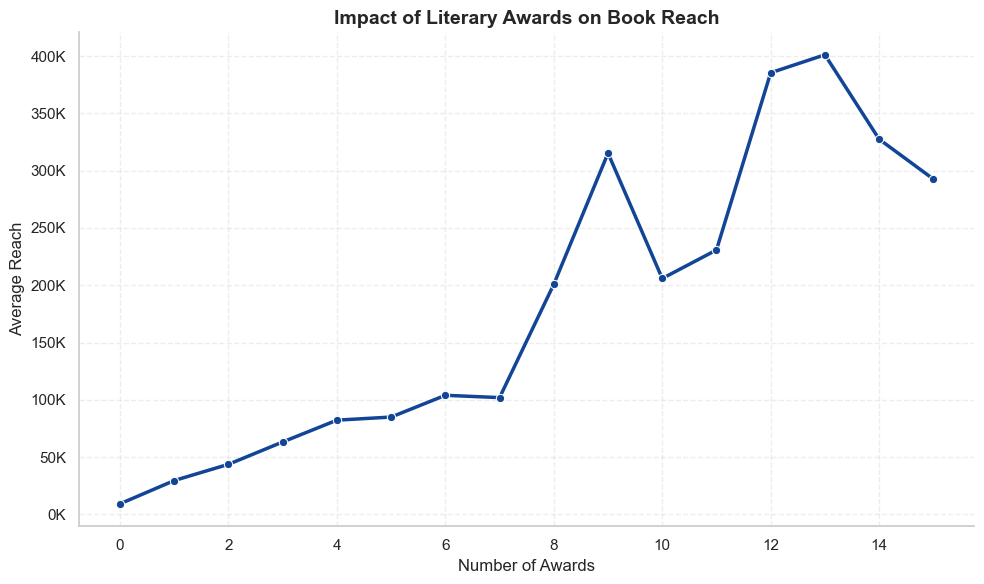

In [ ]:
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

ax = sns.lineplot(
    x=avgpopgrp.index,
    y=avgpopgrp.values,
    marker="o",
    linewidth=2.5,
    color="#124596"
)


ax.set_xlabel("Number of Awards", fontsize=12)
ax.set_ylabel("Average Reach", fontsize=12)

ax.set_title(
    "Impact of Literary Awards on Book Reach",
    fontsize=14,
    weight="bold"
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{int(x/1000)}K')
)


ax.grid(True, linestyle="--", alpha=0.35)


sns.despine()

plt.tight_layout()
plt.show()

In [39]:
final_df


,pages,publishDate,likedPercent,price,description,characters,awards,length,numofchar,numofawards,title,author,bbeScore,...,genres,ratingsByStars,bbeVotes,isbn,isSeries,formatCategory,rating,numRatings,Bestseller,bbenorvotes,numnorRating,likednorPercent,pop_score
0,374,2008-09-14 00:00:00.000000000,96.0,1.806648,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,"["" 'Katniss Everdeen'"", "" 'Peeta Mellark'"", "" ...","["" 'Locus Award Nominee for Best Young Adult B...",Short Book,23,41.0,The Hunger Games,Suzanne Collins,2993816,...,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...","[3444695, 1921313, 745221, 171994, 93557]",30516.0,9780439023481,True,Hardcover,4.33,6376780,1.0,1.000000,0.904704,0.96,0.929293
1,870,2004-09-28 00:00:00.000000000,98.0,2.125848,There is a door at the end of a silent corrido...,"["" 'Sirius Black'"", "" 'Draco Malfoy'"", "" 'Ron ...","["" 'Bram Stoker Award for Works for Young Read...",Long Book,44,9.0,Harry Potter and the Order of the Phoenix,"J.K. Rowling, Mary GrandPré (Illustrator)",2632233,...,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","[1593642, 637516, 222366, 39573, 14526]",26923.0,9780439358071,True,Paperback,4.50,2507623,1.0,0.882258,0.355768,0.98,0.523490
2,324,2006-05-23 00:00:00.000000000,95.0,1.824549,The unforgettable novel of a childhood in a sl...,"["" 'Scout Finch'"", "" 'Atticus Finch'"", "" 'Jem ...","["" 'Pulitzer Prize for Fiction (1961)'"", "" 'Au...",Short Book,14,4.0,To Kill a Mockingbird,Harper Lee,2269402,...,"['Classics', 'Fiction', 'Historical Fiction', ...","[2363896, 1333153, 573280, 149952, 80794]",23328.0,9999999999999,True,Paperback,4.28,4501075,1.0,0.764451,0.638589,0.95,0.694902
3,279,2000-10-10 00:00:00.000000000,94.0,1.824549,Alternate cover edition of ISBN 9780679783268S...,"["" 'Mr. Bennet'"", "" 'Mrs. Bennet'"", "" 'Jane Be...",['No awards'],Short Book,24,0.0,Pride and Prejudice,"Jane Austen, Anna Quindlen (Introduction)",1983116,...,"['Classics', 'Fiction', 'Romance', 'Historical...","[1617567, 816659, 373311, 113934, 76770]",20452.0,9999999999999,False,Paperback,4.26,2998241,1.0,0.670206,0.425375,0.94,0.525803
4,501,2006-09-06 00:00:00.000000000,78.0,1.131402,About three things I was absolutely positive.\...,"["" 'Edward Cullen'"", "" 'Jacob Black'"", "" 'Laur...","["" 'Georgia Peach Book Award (2007)'"", "" 'Buxt...",Standard Book,17,25.0,Twilight,Stephenie Meyer,1459448,...,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...","[1751460, 1113682, 1008686, 542017, 548674]",14874.0,9780316015844,True,Paperback,3.60,4964519,1.0,0.487416,0.704340,0.78,0.668521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52473,0,2011-05-28,94.0,1.824549,The Fateful Trilogy continues with Fractured. ...,NaN,['No awards'],Short Book,0,0.0,Fractured,Cheri Schmidt (Goodreads Author),0,...,"['Vampires', 'Paranormal', 'Young Adult', 'Rom...","[311, 310, 197, 42, 11]",1.0,2940012616562,True,Others,4.00,871,0.0,0.000033,0.000124,0.94,0.094093
52474,190,2011-08-05,95.0,1.824549,"'Anasazi', sequel to 'The Thirteenth Chime' by...",NaN,['No awards'],Short Book,0,0.0,Anasazi,Emma Michaels,0,...,"['Mystery', 'Young Adult']","[16, 14, 5, 2, 0]",1.0,9999999999999,True,Paperback,4.19,37,0.0,0.000033,0.000005,0.95,0.095010
52475,280,2011-03-18,84.0,2.124654,--READERS FAVORITE AWARDS WINNER 2011--Sixteen...,NaN,"[' ""Readers\' Favorite Book Award (2011)"" ']",Short Book,0,1.0,Marked,Kim Richardson (Goodreads Author),0,...,"['Fantasy', 'Young Adult', 'Paranormal', 'Ange...","[2109, 1868, 1660, 647, 390]",1.0,9781461017097,True,Paperback,3.70,6674,0.0,0.000033,0.000947,0.84,0.084669
52476,507,2011-09-01,90.0,1.350667,A POWERFUL TREMOR UNEARTHS AN ANCIENT SECRETBu...,NaN,['No awards'],Standard Book,0,0.0,Wayward Son,"Tom Pollack (Goodreads Author), John Loftus (G...",0,...,"['Fiction', 'Mystery', 'Historical Fiction', '...","[77, 78, 59, 19, 5]",1.0,9781450755634,False,Paperback,3.85,238,0.0,0.000033,0.000034,0.90,0.090030

In [40]:
#Size of Books vs ratiings
final_df['length'].value_counts()

length
Short Book       43923
Standard Book     7846
Long Book          659
Name: count, dtype: int64

In [41]:
grp=final_df.groupby(['length'])

In [42]:
avgbylength=grp['likedPercent'].mean()

C:\Users\aadit\AppData\Local\Temp\ipykernel_13976\2410930921.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


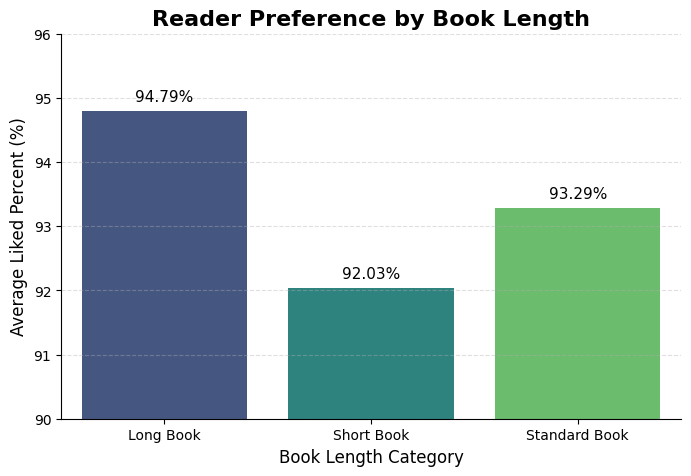

In [43]:

import seaborn as sns


plt.figure(figsize=(8,5))

sns.barplot(
    x=avgbylength.index,
    y=avgbylength.values,
    palette='viridis'
)

plt.title("Reader Preference by Book Length", fontsize=16, weight='bold')
plt.xlabel("Book Length Category", fontsize=12)
plt.ylabel("Average Liked Percent (%)", fontsize=12)

# value labels
for i, v in enumerate(avgbylength.values):
    plt.text(i, v + 0.15, f"{v:.2f}%", ha='center', fontsize=11)

plt.ylim(90,96)

plt.grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()

plt.show()

In [44]:
final_df['numofchar'].corr(final_df['pop_score'])

np.float64(0.14301097624343925)

In [45]:
final_df['numofchar'].describe()

count    52428.000000
mean         1.374743
std          6.888996
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        669.000000
Name: numofchar, dtype: float64

In [46]:
final_df['characters'].isnull().sum()

np.int64(38668)

In [47]:
final_df['numofchar'].describe()

count    52428.000000
mean         1.374743
std          6.888996
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        669.000000
Name: numofchar, dtype: float64

In [48]:
filt=(final_df['numofchar']!=0) & (final_df['numofchar']<=100)

In [49]:
filtered=final_df.loc[filt,:]

In [50]:
bins = [0,5,10,15,20]
filtered['char_bin']=pd.cut(filtered['numofchar'],bins=bins)

C:\Users\aadit\AppData\Local\Temp\ipykernel_13976\3515267988.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['char_bin']=pd.cut(filtered['numofchar'],bins=bins)


In [51]:
grpchar=filtered.groupby(['char_bin'])

C:\Users\aadit\AppData\Local\Temp\ipykernel_13976\1089178553.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grpchar=filtered.groupby(['char_bin'])


In [52]:
binavg=grpchar['likedPercent'].mean()

In [53]:
binavg.sort_values(inplace=True)

C:\Users\aadit\AppData\Local\Temp\ipykernel_13976\1541440645.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


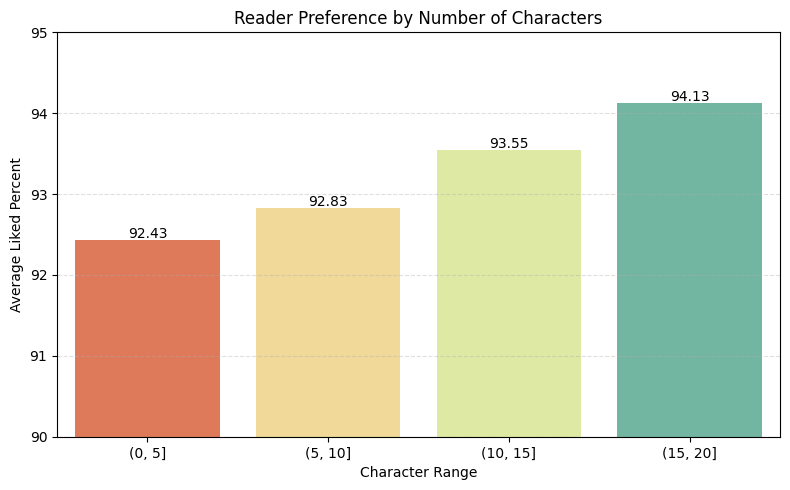

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=binavg.index.astype(str),   
    y=binavg.values,              
    palette=sns.color_palette("Spectral", len(binavg))  
)

plt.xlabel("Character Range")
plt.ylabel("Average Liked Percent")
plt.title("Reader Preference by Number of Characters")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.ylim(90,95)   
for i,v in enumerate(binavg.values):
    plt.text(i, v+0.02, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.show()

In [55]:
final_df['publishDate'].min()

'1820-10-01'

In [56]:
final_df['genres']=final_df['genres'].str.split(',')
genre_df=final_df.explode('genres')

In [57]:
filt=genre_df['genres']!='[]'

In [58]:
genre_df=genre_df[filt]

In [59]:
(genre_df['genres']=='[]').sum()

np.int64(0)

In [60]:
(genre_df['genres']=='').sum()

np.int64(0)

In [61]:
genre_df['genres']=genre_df['genres'].str.replace('[','')

In [62]:
genre_df['genres']=genre_df['genres'].str.replace(']','')

In [63]:
#to get only the contingoues characters
genre_df['genres'] = genre_df['genres'].str.strip()

In [64]:
genre_df['genres'] = genre_df['genres'].str.replace("'", "")

In [65]:
#group by genre
genre_awards = genre_df.groupby('genres')['numofawards'].sum()

In [66]:
genre_df['genres'].unique()

array(['Young Adult', 'Fiction', 'Dystopia', 'Fantasy', 'Science Fiction',
       'Romance', 'Adventure', 'Teen', 'Post Apocalyptic', 'Action',
       'Magic', 'Childrens', 'Audiobook', 'Middle Grade', 'Classics',
       'Science Fiction Fantasy', 'Historical Fiction', 'School',
       'Literature', 'Historical', 'Novels', 'Read For School',
       'High School', 'Historical Romance', 'Classic Literature', 'Adult',
       'Vampires', 'Paranormal', 'Paranormal Romance', 'Supernatural',
       'Urban Fantasy', 'War', 'Holocaust', 'World War II',
       'Books About Books', 'Politics', 'Christian', 'Christian Fiction',
       'Epic Fantasy', 'High Fantasy', 'Civil War', 'Contemporary',
       'Realistic Fiction', 'Coming Of Age', 'Drama', 'Love', 'Humor',
       'Comedy', 'Picture Books', 'Poetry', 'Juvenile', 'Kids',
       'Short Stories', 'Gothic', '19th Century', 'Mystery', 'Thriller',
       'Suspense', 'Mystery Thriller', 'Crime', 'Japan', 'Asia',
       'Adult Fiction', 'Horror', '

In [67]:
genre_awards.describe()

count      982.000000
mean       225.982688
std        976.238235
min          0.000000
25%          1.000000
50%          8.000000
75%         70.500000
max      19412.000000
Name: numofawards, dtype: float64

In [68]:
genre_awards = genre_awards.sort_values(ascending=False)

In [69]:
top_genres=genre_awards.head(10)

In [70]:
top_genres

genres
Fiction               19412.0
Fantasy                8413.0
Young Adult            8164.0
Audiobook              6974.0
Contemporary           6894.0
Historical Fiction     5640.0
Novels                 5434.0
Romance                5383.0
Adult                  4883.0
Historical             4713.0
Name: numofawards, dtype: float64

C:\Users\aadit\AppData\Local\Temp\ipykernel_13976\2780300961.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


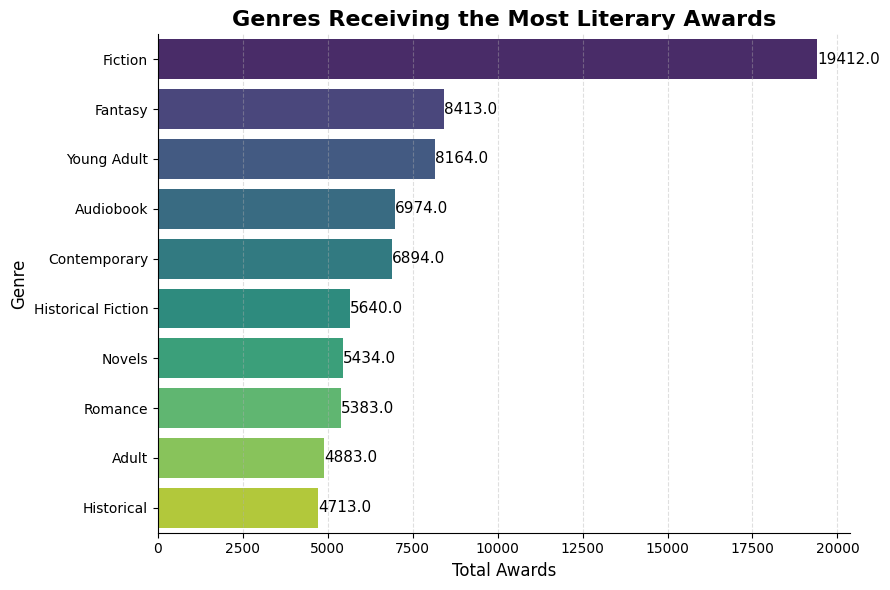

In [ ]:
plt.figure(figsize=(9,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    palette="viridis"
)

plt.title("Genres Receiving the Most Literary Awards", fontsize=16, weight='bold')
plt.xlabel("Total Awards", fontsize=12)
plt.ylabel("Genre", fontsize=12)


for i, v in enumerate(top_genres.values):
    plt.text(v + 1, i, str(v), va='center', fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

In [72]:
genre_df

,pages,publishDate,likedPercent,price,description,characters,awards,length,numofchar,numofawards,title,author,bbeScore,...,genres,ratingsByStars,bbeVotes,isbn,isSeries,formatCategory,rating,numRatings,Bestseller,bbenorvotes,numnorRating,likednorPercent,pop_score
0,374,2008-09-14 00:00:00.000000000,96.0,1.806648,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,"["" 'Katniss Everdeen'"", "" 'Peeta Mellark'"", "" ...","["" 'Locus Award Nominee for Best Young Adult B...",Short Book,23,41.0,The Hunger Games,Suzanne Collins,2993816,...,Young Adult,"[3444695, 1921313, 745221, 171994, 93557]",30516.0,9780439023481,True,Hardcover,4.33,6376780,1.0,1.000000,0.904704,0.96,0.929293
0,374,2008-09-14 00:00:00.000000000,96.0,1.806648,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,"["" 'Katniss Everdeen'"", "" 'Peeta Mellark'"", "" ...","["" 'Locus Award Nominee for Best Young Adult B...",Short Book,23,41.0,The Hunger Games,Suzanne Collins,2993816,...,Fiction,"[3444695, 1921313, 745221, 171994, 93557]",30516.0,9780439023481,True,Hardcover,4.33,6376780,1.0,1.000000,0.904704,0.96,0.929293
0,374,2008-09-14 00:00:00.000000000,96.0,1.806648,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,"["" 'Katniss Everdeen'"", "" 'Peeta Mellark'"", "" ...","["" 'Locus Award Nominee for Best Young Adult B...",Short Book,23,41.0,The Hunger Games,Suzanne Collins,2993816,...,Dystopia,"[3444695, 1921313, 745221, 171994, 93557]",30516.0,9780439023481,True,Hardcover,4.33,6376780,1.0,1.000000,0.904704,0.96,0.929293
0,374,2008-09-14 00:00:00.000000000,96.0,1.806648,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,"["" 'Katniss Everdeen'"", "" 'Peeta Mellark'"", "" ...","["" 'Locus Award Nominee for Best Young Adult B...",Short Book,23,41.0,The Hunger Games,Suzanne Collins,2993816,...,Fantasy,"[3444695, 1921313, 745221, 171994, 93557]",30516.0,9780439023481,True,Hardcover,4.33,6376780,1.0,1.000000,0.904704,0.96,0.929293
0,374,2008-09-14 00:00:00.000000000,96.0,1.806648,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,"["" 'Katniss Everdeen'"", "" 'Peeta Mellark'"", "" ...","["" 'Locus Award Nominee for Best Young Adult B...",Short Book,23,41.0,The Hunger Games,Suzanne Collins,2993816,...,Science Fiction,"[3444695, 1921313, 745221, 171994, 93557]",30516.0,9780439023481,True,Hardcover,4.33,6376780,1.0,1.000000,0.904704,0.96,0.929293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52477,201,2011-05-08,90.0,1.824549,Fighting in Helaman's army is Keturah's deepes...,NaN,['No awards'],Short Book,0,0.0,Daughter of Helaman,Misty Moncur (Goodreads Author),0,...,Lds,"[106, 73, 42, 17, 8]",1.0,9781599554976,True,Paperback,4.02,246,0.0,0.000033,0.000035,0.90,0.090031
52477,201,2011-05-08,90.0,1.824549,Fighting in Helaman's army is Keturah's deepes...,NaN,['No awards'],Short Book,0,0.0,Daughter of Helaman,Misty Moncur (Goodreads Author),0,...,Historical,"[106, 73, 42, 17, 8]",1.0,9781599554976,True,Paperback,4.02,246,0.0,0.000033,0.000035,0.90,0.090031
52477,201,2011-05-08,90.0,1.824549,Fighting in Helaman's army is Keturah's deepes...,NaN,['No awards'],Short Book,0,0.0,Daughter of Helaman,Misty Moncur (Goodreads Author),0,...,Romance,"[106, 73, 42, 17, 8]",1.0,9781599554976,True,Paperback,4.02,246,0.0,0.000033,0.000035,0.90,0.090031
52477,201,2011-05-08,90.0,1.824549,Fighting in Helaman's army is Keturah's deepes...,NaN,['No awards'],Short Book,0,0.0,Daughter of Helaman,Misty Moncur (Goodreads Author),0,...,Adventure,"[106, 73, 42, 17, 8]",1.0,9781599554976,True,Paperback,4.02,246,0.0,0.000033,0.000035,0.90,0.090031


In [73]:
avggrp=genre_df.groupby(['genres'])

In [74]:
avgpricebygenres=avggrp[['price','pop_score','pages','numofchar']].mean()

In [75]:
avgpricebygenres['book_count']=genre_df.groupby('genres').size()

In [76]:
avgpricebygenres.nlargest(10,'pop_score')

,price,pop_score,pages,numofchar,book_count
genres,,,,,
Graffiti,1.715598,0.104260,240.000000,0.000000,1
Street Art,1.715598,0.104260,240.000000,0.000000,1
Classic Literature,1.835158,0.103946,420.878049,5.378049,328
Sierra Leone,1.518207,0.103658,282.500000,5.500000,2
Cameroon,2.470639,0.101054,400.000000,4.000000,1
Greek Mythology,1.832450,0.100084,319.740458,3.641221,131
Benin,1.916923,0.100009,32.000000,0.000000,1
Back To School,1.415853,0.099779,32.000000,0.000000,1
Legal Thriller,1.626903,0.099314,425.583333,2.511905,84


In [77]:
listofgenre=['Fantasy','Fiction','Young Adult','Audiobook','Horror','Novels','Romance','Adult','Historical','Adventure','Action','Crime','Comedy','Vampires','War','Drama','Dragons']

In [78]:
avgpricebygenres.reset_index(inplace=True)

In [79]:
genfinal=avgpricebygenres[avgpricebygenres['genres'].isin(listofgenre)]

In [80]:
genfinal

,genres,price,pop_score,pages,numofchar,book_count
19,Action,1.742458,0.096668,358.072280,2.061103,1342
23,Adult,1.779056,0.096093,352.229248,2.256432,8240
25,Adventure,1.813550,0.097270,351.741235,2.492709,6446
90,Audiobook,1.828461,0.097850,360.982197,2.844837,7302
196,Comedy,1.747607,0.095028,270.115120,2.292955,1164
220,Crime,1.777553,0.095781,354.331790,2.360937,3671
261,Dragons,1.871926,0.096516,384.156800,3.208000,625
262,Drama,1.822562,0.094809,324.731374,1.622103,2416
318,Fantasy,1.872657,0.095249,336.634012,2.264765,15036
330,Fiction,1.841314,0.094814,331.712735,1.995982,31605


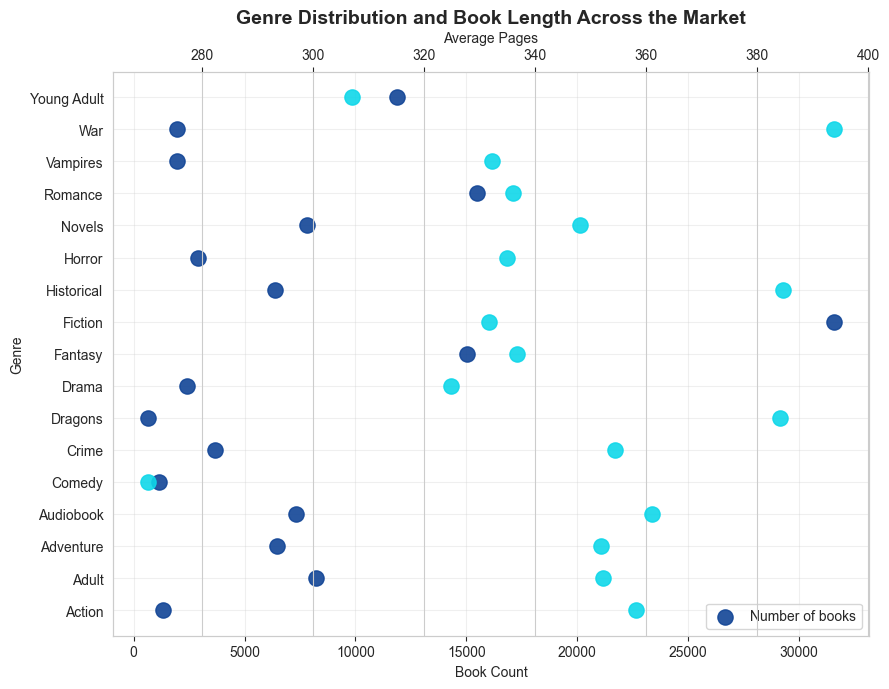

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, ax1 = plt.subplots(figsize=(9,7))

ax1.scatter(
    genfinal['book_count'],
    genfinal['genres'],
    s=120,                
    color="#124596",
    alpha=0.9,
    label='Number of books'
)

ax1.set_xlabel("Book Count")
ax1.set_ylabel("Genre")


ax2 = ax1.twiny()

ax2.scatter(
    genfinal['pages'],
    genfinal['genres'],
    s=120,
    color="#0FD7E9B1",
    alpha=0.9,
     label='Number of Pages'
)

ax2.set_xlabel("Average Pages")

plt.title(
    "Genre Distribution and Book Length Across the Market",
    fontsize=14,
    weight='bold'
)

ax1.legend(loc="lower right")

ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [82]:

final_df['publishDate'] = pd.to_datetime(
    final_df['publishDate'],
    format="%Y-%m-%d",
    errors="coerce"
)

In [83]:
final_df['publishDate']

0              NaT
1              NaT
2              NaT
3              NaT
4              NaT
           ...    
52473   2011-05-28
52474   2011-08-05
52475   2011-03-18
52476   2011-09-01
52477   2011-05-08
Name: publishDate, Length: 52428, dtype: datetime64[ns]

In [84]:
final_df['year']=final_df['publishDate'].dt.year

In [85]:
final_df['Month']=final_df['publishDate'].dt.month

In [86]:
date=final_df[:]

In [87]:
date['year'].fillna(0,inplace=True)

C:\Users\aadit\AppData\Local\Temp\ipykernel_13976\1603478974.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  date['year'].fillna(0,inplace=True)
C:\Users\aadit\AppData\Local\Temp\ipykernel_13976\1603478974.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date['year'].fillna(0,inplace=True)


In [88]:
date=date[date['year']!=0]

In [89]:
filr=date['year']>=2010

In [90]:
date=date[filr]

In [91]:
date['year'].describe()

count    21723.000000
mean      2013.620817
std          2.603388
min       2010.000000
25%       2012.000000
50%       2013.000000
75%       2015.000000
max       2020.000000
Name: year, dtype: float64

In [92]:
date

,pages,publishDate,likedPercent,price,description,characters,awards,length,numofchar,numofawards,title,author,bbeScore,...,bbeVotes,isbn,isSeries,formatCategory,rating,numRatings,Bestseller,bbenorvotes,numnorRating,likednorPercent,pop_score,year,Month
3571,352,2011-03-29,91.0,3.691376,Koschei the Deathless is to Russian folklore w...,NaN,"["" 'Locus Award Nominee for Best Fantasy Novel...",Short Book,0,5.0,"Deathless (Leningrad Diptych, #1)",Catherynne M. Valente (Goodreads Author),908,...,10.0,9780765326300,False,Hardcover,4.00,16038,0.0,0.000328,0.002275,0.91,0.092658,2011.0,3.0
3572,173,2016-04-05,90.0,2.532903,Eleanor West’s Home for Wayward ChildrenNo Sol...,"["" 'Nancy'"", "" 'Jack'"", "" 'Jill'"", "" 'Loreli'""...","["" 'Hugo Award for Best Novella (2017)'"", "" 'N...",Short Book,7,6.0,Every Heart a Doorway,Seanan McGuire (Goodreads Author),908,...,11.0,9780765385505,True,Hardcover,3.81,68525,1.0,0.000360,0.009722,0.90,0.096877,2016.0,4.0
3575,390,2011-08-30,93.0,1.834180,"When Alex finds out he is Unwanted, he expects...",NaN,"[' ""Pennsylvania Young Readers\' Choice Award ...",Short Book,0,4.0,The Unwanteds,Lisa McMann (Goodreads Author),907,...,10.0,9781442407688,True,Hardcover,4.11,29110,0.0,0.000328,0.004130,0.93,0.095957,2011.0,8.0
3578,216,2015-08-26,95.0,2.542389,"Webb Thompson awakes, disoriented and fearful....",NaN,['No awards'],Short Book,0,0.0,Dark Lands: Requiem,Lyn I. Kelly,906,...,10.0,9781483434230,True,Paperback,4.27,656,0.0,0.000328,0.000093,0.95,0.095131,2015.0,8.0
3581,352,2016-07-19,91.0,1.532557,From the New York Times bestselling author of ...,"[' \'Louisa ""Lou"" Clark\'', "" 'Lily Houghton-M...","["" 'Goodreads Choice Award Nominee for Fiction...",Short Book,2,3.0,After You,Jojo Moyes (Goodreads Author),905,...,10.0,9780143108863,True,Paperback,3.73,297548,1.0,0.000328,0.042215,0.91,0.120616,2016.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52473,0,2011-05-28,94.0,1.824549,The Fateful Trilogy continues with Fractured. ...,NaN,['No awards'],Short Book,0,0.0,Fractured,Cheri Schmidt (Goodreads Author),0,...,1.0,2940012616562,True,Others,4.00,871,0.0,0.000033,0.000124,0.94,0.094093,2011.0,5.0
52474,190,2011-08-05,95.0,1.824549,"'Anasazi', sequel to 'The Thirteenth Chime' by...",NaN,['No awards'],Short Book,0,0.0,Anasazi,Emma Michaels,0,...,1.0,9999999999999,True,Paperback,4.19,37,0.0,0.000033,0.000005,0.95,0.095010,2011.0,8.0
52475,280,2011-03-18,84.0,2.124654,--READERS FAVORITE AWARDS WINNER 2011--Sixteen...,NaN,"[' ""Readers\' Favorite Book Award (2011)"" ']",Short Book,0,1.0,Marked,Kim Richardson (Goodreads Author),0,...,1.0,9781461017097,True,Paperback,3.70,6674,0.0,0.000033,0.000947,0.84,0.084669,2011.0,3.0
52476,507,2011-09-01,90.0,1.350667,A POWERFUL TREMOR UNEARTHS AN ANCIENT SECRETBu...,NaN,['No awards'],Standard Book,0,0.0,Wayward Son,"Tom Pollack (Goodreads Author), John Loftus (G...",0,...,1.0,9781450755634,False,Paperback,3.85,238,0.0,0.000033,0.000034,0.90,0.090030,2011.0,9.0


In [97]:
seasonal_pop = date.groupby('Month')['numRatings'].mean()

In [98]:
seasonal_pop

Month
1.0     5506.714442
2.0     7291.264794
3.0     7390.964838
4.0     8040.827030
5.0     7726.211164
6.0     8560.095122
7.0     7558.704762
8.0     7912.039586
9.0     8569.882498
10.0    8668.359490
11.0    7115.277635
12.0    5599.101531
Name: numRatings, dtype: float64

C:\Users\aadit\AppData\Local\Temp\ipykernel_13976\841272590.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


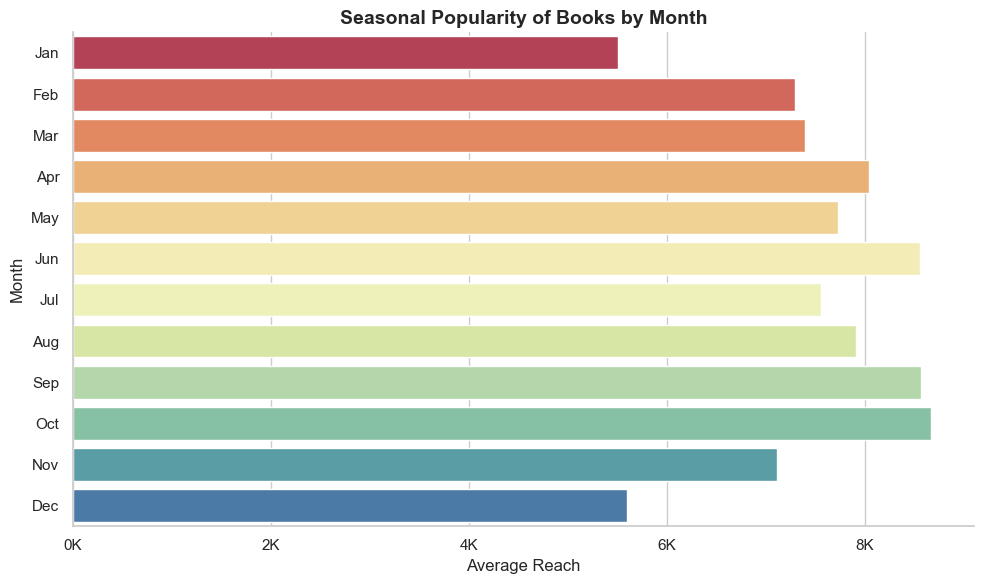

In [106]:

from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

ax = sns.barplot(
    y=month_labels,                
    x=seasonal_pop.values,
    palette="Spectral",             
)

# Title and labels
ax.set_title("Seasonal Popularity of Books by Month", fontsize=14, weight="bold")
ax.set_xlabel("Average Reach")
ax.set_ylabel("Month")


ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{int(x/1000)}K')
)

sns.despine()

plt.tight_layout()
plt.show()